# Multivariable Regression with Scikit-learn  
# diamond-price-prediction
A supervised machine learning project that predicts diamond prices using regression techniques. The model is trained on the classic Diamonds dataset (53,940 samples) and leverages both numerical and categorical features to produce accurate price estimates.
# Diamond Data
This classic dataset contains the prices and other attributes of almost 54,000 diamonds. 
# Data Link
https://www.kaggle.com/datasets/shivam2503/diamonds

# Data Dictionary

- price: price in US dollars (\$326--\$18,823)
- carat : weight of the diamond (0.2--5.01)
- cut : quality of the cut (Fair, Good, Very Good, Premium, Ideal)
- color : diamond colour, from J (worst) to D (best)
- clarity: a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
- x :length in mm (0--10.74)
- y :width in mm (0--58.9)
- z :depth in mm (0--31.8)
- depth :total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
- table: width of top of diamond relative to widest point (43--95)

In [48]:
# import libraries
import pandas as pd                     # for loading and working with data tables
import numpy as np
import matplotlib.pyplot as plt        # for plotting graphs

from sklearn.model_selection import train_test_split   # to split data into training and testing sets
from sklearn.preprocessing import StandardScaler, OneHotEncoder      # to scale features and convert categorical features
from sklearn.linear_model import LinearRegression      # linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
# functions to evaluate the model

plt.rcParams["figure.figsize"] = (7, 4)   # set default figure size
plt.rcParams["axes.grid"] = True          # show grid on plots

In [49]:
# load data
df = pd.read_csv("diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [50]:
# get information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [51]:
# show statical information about numeric data
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [52]:
# show statical information about categoric data
df.describe(include='object')

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


In [53]:
# define features and Target
# drop Unnamed: 0 
# Use np.log to Compress the skewed distribution into a normal-like shape. Makes cheap and expensive diamonds equally influential. Eliminates the negative prediction problem.
X = df.drop(columns=["price", "Unnamed: 0"], axis=1)
y = np.log(df["price"])

In [54]:
X.value_counts()

carat  cut      color  clarity  depth  table  x      y      z   
0.79   Ideal    G      SI1      62.3   57.0   5.90   5.85   3.66    5
0.31   Ideal    F      IF       61.2   57.0   4.35   4.38   2.67    3
2.42   Premium  J      VS2      61.3   59.0   8.61   8.58   5.27    3
0.50   Good     D      SI1      64.1   56.0   5.03   4.98   3.21    2
0.55   Ideal    H      SI1      61.5   54.0   5.30   5.33   3.27    2
                                                                   ..
4.01   Premium  I      I1       61.0   61.0   10.14  10.10  6.17    1
                J      I1       62.5   62.0   10.02  9.94   6.24    1
4.13   Fair     H      I1       64.8   61.0   10.00  9.85   6.43    1
4.50   Fair     J      I1       65.8   58.0   10.23  10.16  6.72    1
0.20   Premium  D      VS2      61.7   60.0   3.77   3.72   2.31    1
Name: count, Length: 53595, dtype: int64

In [55]:
# split data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1 )

## Feature Scaling for numeric Features

In [56]:
# define numeric features and object features
num_cols = X_train.select_dtypes("number").columns

# feature scaling 
scaler = StandardScaler()  

# Instantiate the pipeline
num_pipe = make_pipeline(scaler)

# Make the tuple for ColumnTransformer
num_tuple = ('numeric',num_pipe,num_cols)
num_tuple


('numeric',
 Pipeline(steps=[('standardscaler', StandardScaler())]),
 Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object'))

## One Hot Encoder for categorical Features

In [57]:
# Create the preprocessing pipeline for categorical data
cat_selector =  X_train.select_dtypes('object').columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_pipe = make_pipeline(ohe)

cat_tuple = ('categorical',cat_pipe, cat_selector)
cat_tuple

('categorical',
 Pipeline(steps=[('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 Index(['cut', 'color', 'clarity'], dtype='object'))

In [58]:

# Create the preprocessing ColumnTransformer
preprocessor = ColumnTransformer([cat_tuple, num_tuple],
verbose_feature_names_out=False)

preprocessor

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['cut', 'color', 'clarity'], dtype='object')),
                                ('numeric',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object'))],
                  verbose_feature_names_out=False)

In [59]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['cut', 'color', 'clarity'], dtype='object')),
                                ('numeric',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object'))],
                  verbose_feature_names_out=False)

In [60]:
x_train_transformed=preprocessor.transform(X_train)
x_test_transformed=preprocessor.transform(X_test)

In [61]:
# Train the model
model = LinearRegression()
# create a linear regression model

model.fit(x_train_transformed, y_train)
# train the model using training data (learn weights and bias)

LinearRegression()

In [62]:
# Show coefficients
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [-0.09677521 -0.00545001  0.05927237  0.01455302  0.02839982  0.21078573
  0.15055007  0.12139348  0.05312026 -0.04674467 -0.17398725 -0.31511762
 -0.71071885  0.38843661 -0.09799193 -0.26602218  0.11202223  0.04482898
  0.29763943  0.23180571 -0.27294059  0.07386862  0.02008387  1.30089403
  0.03252997  0.02506259]
Bias: 7.704067364564181


In [63]:
# use np.exp to Convert log predictions back to real dollar prices. Since e^x is always positive, negative predictions become mathematically impossible.
# prdicted vs. Actual
y_pred = model.predict(x_test_transformed)
# use the trained model to make predictions
y_pred_actual = np.exp(y_pred)
results = pd.DataFrame({
    "Actual Price":  np.exp(y_test.values),     # real prices
    "Predicted Price": y_pred_actual         # predicted prices
})

results.head(10)


,Actual Price,Predicted Price
0,564.0,543.057002
1,5914.0,5911.361313
2,2562.0,2648.990411
3,537.0,620.024834
4,5964.0,5974.337305
5,984.0,1258.839626
6,5247.0,5156.860207
7,611.0,689.698494
8,9645.0,9842.827331
9,1162.0,1112.987066


In [64]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)  
# average difference between real and predicted values

rmse = mean_squared_error(y_test, y_pred) ** 0.5  
# error with more penalty for large mistakes (square then root)

r2 = r2_score(y_test, y_pred)  
# how well the model fits the data (closer to 1 is better)

# print results
print("MAE  =", round(mae, 3))   # average error
print("RMSE =", round(rmse, 3))  # weighted error
print("R^2  =", round(r2, 3))    # model performance

MAE  = 0.111
RMSE = 0.158
R^2  = 0.975


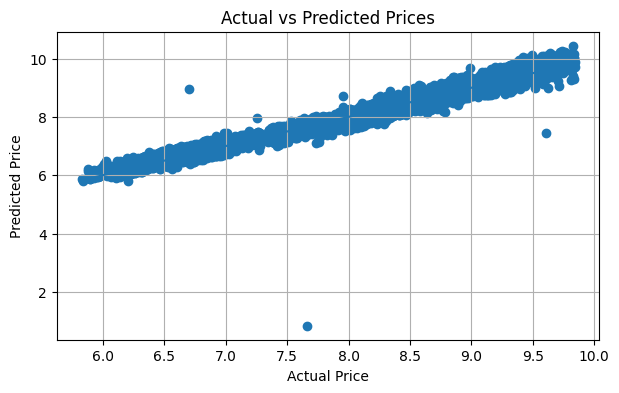

In [65]:
# Visualize model with real data

plt.scatter(y_test, y_pred)  
# plot actual values vs predicted values (each point = one house)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])  
# draw diagonal line (perfect prediction line)

plt.title("Actual vs Predicted Prices")  
# title of the graph

plt.xlabel("Actual Price")  
# x-axis: real prices

plt.ylabel("Predicted Price")  
# y-axis: predicted prices

plt.show()  
# display the graph